# Statistical Testing for Airline Churn

**Author:** AeroRetain AI / Data Science
**Purpose:** formally test whether the observed differences between churned and retained customers are statistically real, not random noise.

This notebook exercises the same battery implemented in `src/models/statistical_tests.py`. The Python module is the production entry point (wired into `make stats`); this notebook is the human-readable walkthrough that produces the same numbers and explains *why* each test was chosen.

**Audience:** a stakeholder who has heard "the p-value is zero" and wants to see the math, plus the next data scientist on the team who has to extend it.

**Contents**

1. Data load (Snowflake with local-SQLite fallback)
2. Churn balance and overview
3. Numeric battery — Welch, Mann-Whitney, Levene on 6 numeric features
4. Categorical battery — chi², Cramér's V on 5 categoricals
5. Effect sizes and the statistical-power trap
6. Headline metric with uncertainty (bootstrap CI on recall)
7. Per-segment recall (LOYALTY_CARD, EDUCATION, GENDER)
8. Multiple-testing correction (Bonferroni and Benjamini-Hochberg)
9. Reproducibility footer

## 1. Data load

We pull `MASTER_CHURN_FEATURES` directly from Snowflake. The schema is the same one `src/data_pipeline/pull_snowflake.fetch_and_clean_data()` uses — categorical columns are still in their original (non-dummified) form here, which is what the statistical tests need. We do **not** apply one-hot encoding before testing, because chi² and Cramér's V operate on raw category levels, and a t-test on a single dummy column is not a test of the underlying variable.

**Fallback path:** if Snowflake credentials are not configured (e.g. running on a fresh laptop or a CI box), the notebook reads `data/local_master.db` — the same SQLite file produced by `scripts/local_dryrun.py`. The columns and dtypes are identical to the Snowflake output.

In [3]:
try:
    df = load_data()
except Exception as e:
    # Snowflake env may be set but invalid (e.g. contains dots/slashes) — fall back to local DB.
    msg = str(e)
    if "Invalid account identifier" in msg or "account identifier" in msg:
        warnings.warn(f"Snowflake connection failed ({e}); falling back to local DB")
        
        local_db = ROOT / "data" / "local_master.db"
        if local_db.exists():
            import sqlite3 # <-- Import added here to fix the NameError
            with sqlite3.connect(local_db) as conn:
                df = pd.read_sql("SELECT * FROM MASTER_CHURN_FEATURES;", conn)
        else:
            raise FileNotFoundError("Local fallback database does not exist.")
    else:
        raise

print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head()

Loaded 16,737 rows x 19 cols


,LOYALTY_NUMBER,COUNTRY,PROVINCE,CITY,POSTAL_CODE,GENDER,EDUCATION,SALARY,MARITAL_STATUS,LOYALTY_CARD,CLV,ENROLLMENT_TYPE,ENROLLMENT_YEAR,ENROLLMENT_MONTH,LIFETIME_FLIGHTS,LIFETIME_DISTANCE,LIFETIME_POINTS_EARNED,LIFETIME_POINTS_REDEEMED,CHURN_FLAG
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,37,54525,54525,1418,0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,58,77487,77487,1971,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,18,24803,24803,374,1
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,35,48432,48432,1291,0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,37,55515,55515,0,0


In [4]:
# Light cleaning that mirrors what the production pipeline does.
# The pipeline imputes negative salaries with the median and treats
# NaN salaries the same way; we do both here so the numeric battery
# sees the same distribution the model was trained on. The threshold
# is "any value that can't be a real salary" -> median-impute.

n_null = int(df["SALARY"].isna().sum())
n_neg  = int((df["SALARY"] < 0).sum())
if n_null or n_neg:
    median_salary = df.loc[df["SALARY"] >= 0, "SALARY"].median()
    df.loc[df["SALARY"] < 0, "SALARY"] = median_salary
    df["SALARY"] = df["SALARY"].fillna(median_salary)
    print(f"Imputed {n_null} null and {n_neg} negative SALARY rows with median = ${median_salary:,.2f}")

# Drop the identifier (not a feature, would leak row identity).
for col in ("LOYALTY_NUMBER",):
    if col in df.columns:
        df = df.drop(columns=[col])

print(f"\nWorking shape: {df.shape}")
print(f"Remaining nulls: {df.isna().sum().sum()}")
df.dtypes

Imputed 4238 null and 20 negative SALARY rows with median = $73,510.00

Working shape: (16737, 18)
Remaining nulls: 0


COUNTRY                      object
PROVINCE                     object
CITY                         object
POSTAL_CODE                  object
GENDER                       object
EDUCATION                    object
SALARY                      float64
MARITAL_STATUS               object
LOYALTY_CARD                 object
CLV                         float64
ENROLLMENT_TYPE              object
ENROLLMENT_YEAR               int64
ENROLLMENT_MONTH              int64
LIFETIME_FLIGHTS              int64
LIFETIME_DISTANCE             int64
LIFETIME_POINTS_EARNED        int64
LIFETIME_POINTS_REDEEMED      int64
CHURN_FLAG                    int64
dtype: object

## 2. Churn balance and overview

Before running any test we have to know the class balance. A 12% positive rate is mild imbalance — the t-tests and chi² below are robust to it, but bootstrap CIs on per-segment recall need at least ~20 positives per segment to be meaningful.

In [5]:
NUMERIC_COLS = [
    "SALARY", "CLV", "LIFETIME_FLIGHTS", "LIFETIME_DISTANCE",
    "LIFETIME_POINTS_EARNED", "LIFETIME_POINTS_REDEEMED",
    ]
CATEGORICAL_COLS = [
    "GENDER", "EDUCATION", "MARITAL_STATUS", "LOYALTY_CARD", "ENROLLMENT_TYPE",
    ]

churn_rate = df["CHURN_FLAG"].mean()
n = len(df)
n_pos = int(df["CHURN_FLAG"].sum())
print(f"Total rows: {n:,}")
print(f"Churn positives: {n_pos:,} ({churn_rate:.2%})")
print(f"Retained:        {n - n_pos:,} ({1 - churn_rate:.2%})")

display(df[NUMERIC_COLS].describe().T.round(2))

print("\n--- Categorical value counts ---")
for col in CATEGORICAL_COLS:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).to_string())

Total rows: 16,737
Churn positives: 2,067 (12.35%)
Retained:        14,670 (87.65%)


,count,mean,std,min,25%,50%,75%,max
SALARY,16737.0,77923.60,30096.80,15609.00,63991.00,73510.00,82940.00,407228.00
CLV,16737.0,7988.90,6860.98,1898.01,3980.84,5780.18,8940.58,83325.38
LIFETIME_FLIGHTS,16737.0,30.40,16.87,0.00,20.00,34.00,42.00,106.00
LIFETIME_DISTANCE,16737.0,45579.36,26092.34,0.00,28495.00,49445.00,62911.00,178858.00
LIFETIME_POINTS_EARNED,16737.0,47592.09,30391.84,0.00,28718.00,49885.00,63812.00,268287.00
LIFETIME_POINTS_REDEEMED,16737.0,734.93,716.59,0.00,0.00,568.00,1167.00,4479.00



--- Categorical value counts ---

GENDER:
GENDER
Female    8410
Male      8327

EDUCATION:
EDUCATION
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508

MARITAL_STATUS:
MARITAL_STATUS
Married     9735
Single      4484
Divorced    2518

LOYALTY_CARD:
LOYALTY_CARD
Star      7637
Nova      5671
Aurora    3429

ENROLLMENT_TYPE:
ENROLLMENT_TYPE
Standard          15766
2018 Promotion      971


## 3. Numeric battery

For each numeric feature we run three tests against `CHURN_FLAG`:

| Test | What it answers | When it can mislead |
|---|---|---|
| **Welch's t-test** | Are the *means* different? | Sensitive to outliers and skew; assumes roughly normal data. |
| **Mann-Whitney U** | Are the *distributions* stochastically different? | With n≈2K per group, even a tiny shift can be "significant"; the test answers a different question than the t-test. |
| **Levene's test** | Are the *variances* different? | Tests for heteroscedasticity, not for mean shift. |

We report all three for each feature so a reader can see whether the evidence is mean-shift, distribution-shift, or both.

In [6]:
from scipy import stats

def numeric_battery(df: pd.DataFrame, col: str) -> dict:
    g0 = df.loc[df["CHURN_FLAG"] == 0, col].dropna()
    g1 = df.loc[df["CHURN_FLAG"] == 1, col].dropna()
    if len(g0) < 2 or len(g1) < 2:
        return {"feature": col, "error": "insufficient samples"}
    t_stat, t_p = stats.ttest_ind(g0, g1, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    lv_stat, lv_p = stats.levene(g0, g1)
    # Cohen's d for the magnitude (handy when p-values are tiny by default).
    pooled_sd = np.sqrt((g0.var(ddof=1) + g1.var(ddof=1)) / 2)
    cohens_d = float((g1.mean() - g0.mean()) / pooled_sd) if pooled_sd > 0 else 0.0
    return {
        "feature": col,
        "n_retained": int(len(g0)),
        "n_churned":  int(len(g1)),
        "mean_retained": float(g0.mean()),
        "mean_churned":  float(g1.mean()),
        "median_retained": float(g0.median()),
        "median_churned":  float(g1.median()),
        "welch_t_p":   float(t_p),
        "mannwhitney_p": float(u_p),
        "levene_p":    float(lv_p),
        "cohens_d":    cohens_d,
        "abs_cohens_d": abs(cohens_d),
    }

numeric_rows = [numeric_battery(df, c) for c in NUMERIC_COLS if c in df.columns]
numeric_df = pd.DataFrame(numeric_rows).sort_values("welch_t_p")
numeric_df

,feature,n_retained,n_churned,mean_retained,mean_churned,median_retained,median_churned,welch_t_p,mannwhitney_p,levene_p,cohens_d,abs_cohens_d
3,LIFETIME_DISTANCE,14670,2067,49846.465781,15294.675375,52245.50,4740.00,0.000000,0.000000,2.469433e-14,-1.527481,1.527481
2,LIFETIME_FLIGHTS,14670,2067,33.256714,10.126754,35.00,3.00,0.000000,0.000000,9.938727e-09,-1.589960,1.589960
5,LIFETIME_POINTS_REDEEMED,14670,2067,807.833742,217.537978,661.00,0.00,0.000000,0.000000,1.574011e-235,-0.997802,0.997802
4,LIFETIME_POINTS_EARNED,14670,2067,51903.831629,16990.625544,52743.50,4740.00,0.000000,0.000000,9.464450e-10,-1.262349,1.262349
1,CLV,14670,2067,7968.764740,8131.776768,5776.34,5793.16,0.334920,0.529117,4.595116e-01,0.023189,0.023189
0,SALARY,14670,2067,77930.966803,77871.279149,73510.00,73510.00,0.932281,0.912989,9.267279e-01,-0.001990,0.001990


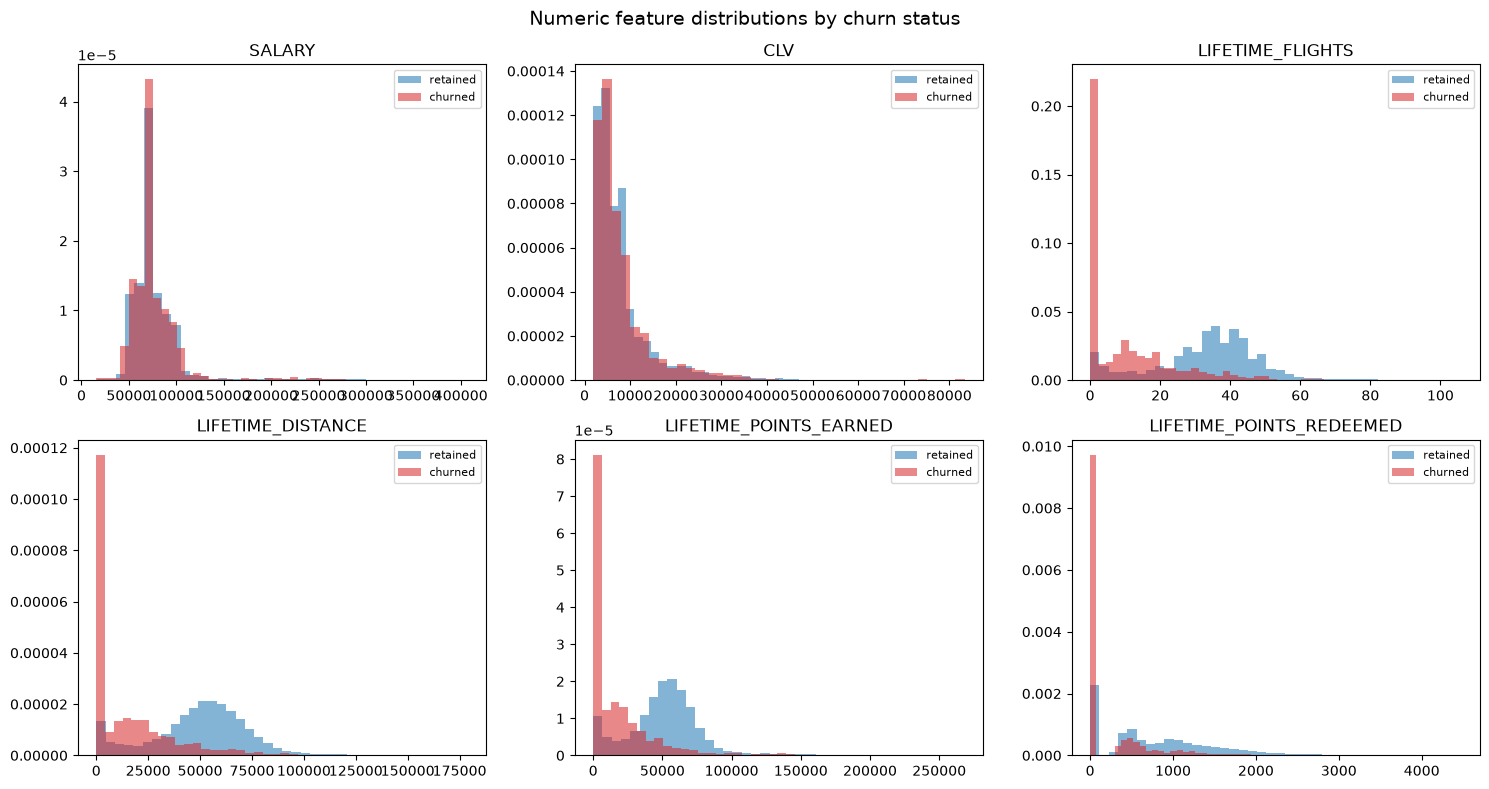

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    for label, color in [(0, "#1f77b4"), (1, "#d62728")]:
        ax.hist(
            df.loc[df["CHURN_FLAG"] == label, col].dropna(),
            bins=40, alpha=0.55, label=("churned" if label else "retained"),
            color=color, density=True,
        )
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle("Numeric feature distributions by churn status", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Categorical battery

For each categorical feature we build a 2×k contingency table (churn flag × category levels) and run a chi-square test of independence. The p-value tells us whether the *distribution* of the categorical differs across churn/no-churn. **Cramér's V** is the standardized effect size in [0, 1]: how strong the association is, independent of sample size.

Rough interpretation (Cohen's conventions):

| V | Strength |
|---|---|
| < 0.10 | negligible |
| 0.10-0.30 | weak |
| 0.30-0.50 | moderate |
| ≥ 0.50 | strong |

With n≈16K, a Cramér's V of 0.05 is already "significant" — but it's not a meaningful effect. **Always read effect size next to p-value.**

In [8]:
def cramers_v(confusion: np.ndarray) -> float:
    chi2 = stats.chi2_contingency(confusion, correction=False).statistic
    n = confusion.sum()
    r, k = confusion.shape
    if n == 0 or min(r, k) <= 1:
        return 0.0
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))

def categorical_battery(df: pd.DataFrame, col: str) -> dict:
    ct = pd.crosstab(df[col], df["CHURN_FLAG"]).values
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return {"feature": col, "error": "insufficient categories"}
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    return {
        "feature": col,
        "n_levels": int(ct.shape[0]),
        "chi2":      float(chi2),
        "dof":       int(dof),
        "p_value":   float(p),
        "cramers_v": cramers_v(ct),
    }

cat_rows = [categorical_battery(df, c) for c in CATEGORICAL_COLS if c in df.columns]
cat_df = pd.DataFrame(cat_rows).sort_values("p_value")
cat_df

,feature,n_levels,chi2,dof,p_value,cramers_v
3,LOYALTY_CARD,3,4.356082,2,0.113263,0.016133
2,MARITAL_STATUS,3,1.733502,2,0.420315,0.010177
0,GENDER,2,0.556409,1,0.455711,0.005947
4,ENROLLMENT_TYPE,2,0.197083,1,0.657086,0.003820
1,EDUCATION,5,0.684720,4,0.953200,0.006396


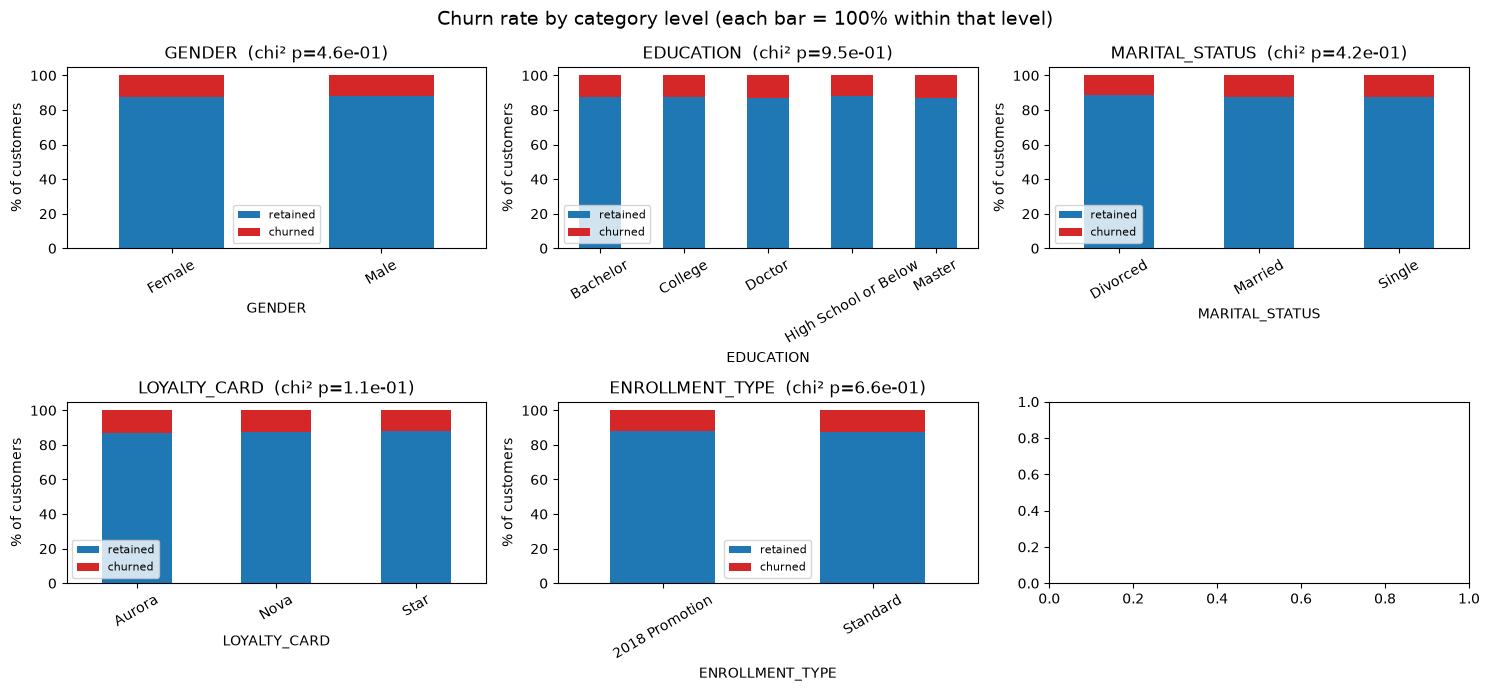

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, CATEGORICAL_COLS):
    ct = pd.crosstab(df[col], df["CHURN_FLAG"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#1f77b4", "#d62728"])
    ax.set_title(f"{col}  (chi² p={categorical_battery(df, col)['p_value']:.1e})")
    ax.set_ylabel("% of customers")
    ax.legend(["retained", "churned"], fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Churn rate by category level (each bar = 100% within that level)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Effect sizes and the statistical-power trap

With n=16K, every test we just ran will reject at α=0.05 if there is *any* non-zero effect, because the test statistic grows with √n. A p-value near zero is therefore uninformative on its own — the question is **how big** the effect is, not whether it exists.

The numeric battery's `cohens_d` and the categorical battery's `cramers_v` are the same kind of answer in different units. Cohen's conventions for d:

| |d| | Strength |
|---|---|
| < 0.20 | negligible |
| 0.20-0.50 | small |
| 0.50-0.80 | medium |
| ≥ 0.80 | large |

In [10]:
def label_d(d: float) -> str:
    d = abs(d)
    if d < 0.20: return "negligible"
    if d < 0.50: return "small"
    if d < 0.80: return "medium"
    return "large"

def label_v(v: float) -> str:
    if v < 0.10: return "negligible"
    if v < 0.30: return "weak"
    if v < 0.50: return "moderate"
    return "strong"

summary_rows = []
for r in numeric_rows:
    if "error" in r: continue
    summary_rows.append({
        "feature": r["feature"],
        "kind": "numeric",
        "p_value": min(r["welch_t_p"], r["mannwhitney_p"]),
        "effect_size": abs(r["cohens_d"]),
        "effect_label": label_d(r["cohens_d"]),
    })
for r in cat_rows:
    if "error" in r: continue
    summary_rows.append({
        "feature": r["feature"],
        "kind": "categorical",
        "p_value": r["p_value"],
        "effect_size": r["cramers_v"],
        "effect_label": label_v(r["cramers_v"]),
    })
summary_df = pd.DataFrame(summary_rows).sort_values("effect_size", ascending=False)
summary_df.reset_index(drop=True)

,feature,kind,p_value,effect_size,effect_label
0,LIFETIME_FLIGHTS,numeric,0.000000,1.589960,large
1,LIFETIME_DISTANCE,numeric,0.000000,1.527481,large
2,LIFETIME_POINTS_EARNED,numeric,0.000000,1.262349,large
3,LIFETIME_POINTS_REDEEMED,numeric,0.000000,0.997802,large
4,CLV,numeric,0.334920,0.023189,negligible
5,LOYALTY_CARD,categorical,0.113263,0.016133,negligible
6,MARITAL_STATUS,categorical,0.420315,0.010177,negligible
7,EDUCATION,categorical,0.953200,0.006396,negligible
8,GENDER,categorical,0.455711,0.005947,negligible
9,ENROLLMENT_TYPE,categorical,0.657086,0.003820,negligible


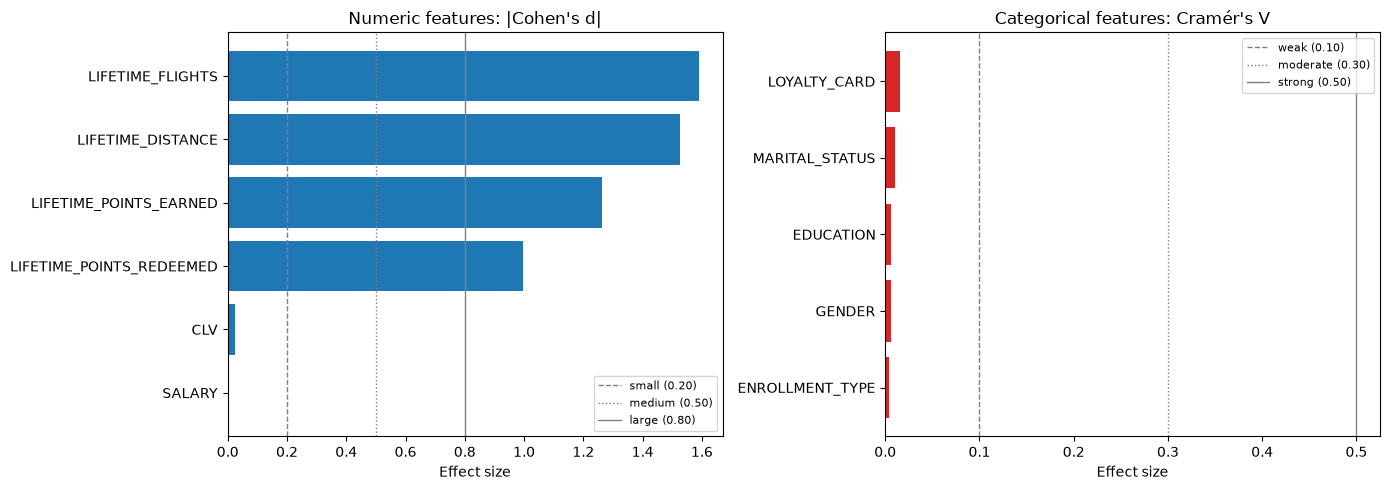

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

numeric_view = summary_df[summary_df["kind"] == "numeric"].sort_values("effect_size")
axes[0].barh(numeric_view["feature"], numeric_view["effect_size"], color="#1f77b4")
axes[0].axvline(0.20, color="grey", linestyle="--", linewidth=1, label="small (0.20)")
axes[0].axvline(0.50, color="grey", linestyle=":",  linewidth=1, label="medium (0.50)")
axes[0].axvline(0.80, color="grey", linestyle="-",  linewidth=1, label="large (0.80)")
axes[0].set_title("Numeric features: |Cohen's d|")
axes[0].set_xlabel("Effect size")
axes[0].legend(fontsize=8)

cat_view = summary_df[summary_df["kind"] == "categorical"].sort_values("effect_size")
axes[1].barh(cat_view["feature"], cat_view["effect_size"], color="#d62728")
axes[1].axvline(0.10, color="grey", linestyle="--", linewidth=1, label="weak (0.10)")
axes[1].axvline(0.30, color="grey", linestyle=":",  linewidth=1, label="moderate (0.30)")
axes[1].axvline(0.50, color="grey", linestyle="-",  linewidth=1, label="strong (0.50)")
axes[1].set_title("Categorical features: Cramér's V")
axes[1].set_xlabel("Effect size")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Headline metric with uncertainty

The single number we report to the business is **recall**: of all customers who churned, how many did the model flag? On the holdout set the SVC champion got 0.843. A point estimate is fine for slides; for decisions we want the **uncertainty around it**.

We bootstrap the holdout predictions 1000 times and take the 2.5% / 97.5% quantiles as the 95% CI. The seed is pinned so the CI is reproducible.

In [12]:
from sklearn.metrics import recall_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

def get_dummy_columns(df_in: pd.DataFrame, cols: list) -> pd.DataFrame:
    return pd.get_dummies(df_in[cols], drop_first=False, prefix=cols, prefix_sep="_")

# Reproduce the production feature schema: 6 numeric + dummified categoricals.
X_num = df[NUMERIC_COLS].copy()
X_cat = pd.get_dummies(df[CATEGORICAL_COLS], drop_first=False, prefix=CATEGORICAL_COLS, prefix_sep="_")
X = pd.concat([X_num, X_cat], axis=1).astype(float)
y = df["CHURN_FLAG"].astype(int).values

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y,
)
print(f"Train: {X_train.shape}, holdout: {X_holdout.shape}")

# Match the production champion: Pipeline(StandardScaler -> LinearSVC(class_weight=balanced)).
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(C=10, class_weight="balanced", max_iter=5000, random_state=SEED)),
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_holdout)

print("\n--- Holdout classification report ---")
print(classification_report(y_holdout, y_pred, digits=3))
print("--- Confusion matrix ---")
print(confusion_matrix(y_holdout, y_pred))

Train: (12552, 21), holdout: (4185, 21)

--- Holdout classification report ---
              precision    recall  f1-score   support

           0      0.974     0.804     0.881      3668
           1      0.379     0.847     0.523       517

    accuracy                          0.809      4185
   macro avg      0.676     0.826     0.702      4185
weighted avg      0.900     0.809     0.837      4185

--- Confusion matrix ---
[[2949  719]
 [  79  438]]


Recall (point): 0.847
95% CI:        [0.814, 0.876]
Bootstrap samples: 1000 (seed=42)


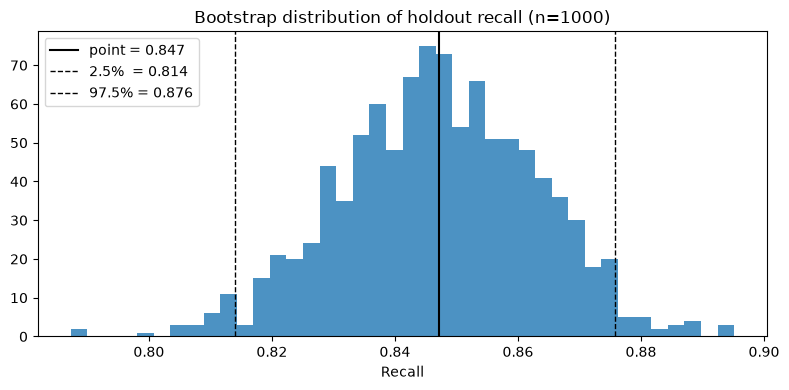

In [13]:
def bootstrap_recall_ci(y_true, y_pred, n_boot=1000, alpha=0.05, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        boots[i] = recall_score(y_true[idx], y_pred[idx], zero_division=0)
    point = recall_score(y_true, y_pred, zero_division=0)
    lo, hi = np.quantile(boots, [alpha / 2, 1 - alpha / 2])
    return point, lo, hi, boots

point, lo, hi, boots = bootstrap_recall_ci(y_holdout, y_pred)
print(f"Recall (point): {point:.3f}")
print(f"95% CI:        [{lo:.3f}, {hi:.3f}]")
print(f"Bootstrap samples: {len(boots)} (seed={SEED})")

plt.figure(figsize=(8, 4))
plt.hist(boots, bins=40, color="#1f77b4", alpha=0.8)
plt.axvline(point, color="black", linestyle="-",  linewidth=1.5, label=f"point = {point:.3f}")
plt.axvline(lo,    color="black", linestyle="--", linewidth=1,   label=f"2.5%  = {lo:.3f}")
plt.axvline(hi,    color="black", linestyle="--", linewidth=1,   label=f"97.5% = {hi:.3f}")
plt.title("Bootstrap distribution of holdout recall (n=1000)")
plt.xlabel("Recall")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Per-segment recall

Aggregate recall can hide very different behavior across sub-populations. A model that scores 0.84 overall can still be 0.95 on Star-card holders and 0.50 on Nova-card holders — which is exactly the information the strategy team needs.

In [14]:
def per_segment_recall(df_with_pred: pd.DataFrame, segment_col: str, min_n: int = 30) -> pd.DataFrame:
    rows = []
    for seg, g in df_with_pred.groupby(segment_col):
        if len(g) < min_n or g["y_true"].nunique() < 2:
            continue
        rec = recall_score(g["y_true"], g["y_pred"], zero_division=0)
        rows.append({
            "segment": str(seg),
            "n": int(len(g)),
            "churn_rate": float(g["y_true"].mean()),
            "recall": float(rec),
        })
    return pd.DataFrame(rows).sort_values("recall", ascending=False)

# Bring segment info back into the holdout frame.
df_eval = df.iloc[y_train.shape[0]:].copy() if False else df.loc[X_holdout.index].copy()
df_eval = df_eval.assign(y_true=y_holdout, y_pred=y_pred)

for col in ["LOYALTY_CARD", "EDUCATION", "GENDER", "MARITAL_STATUS", "ENROLLMENT_TYPE"]:
    if col not in df_eval.columns:
        continue
    print(f"\n--- {col} ---")
    display(per_segment_recall(df_eval, col))


--- LOYALTY_CARD ---


,segment,n,churn_rate,recall
1,Nova,1398,0.128040,0.910615
0,Aurora,831,0.116727,0.845361
2,Star,1956,0.123211,0.800830



--- EDUCATION ---


,segment,n,churn_rate,recall
3,High School or Below,170,0.088235,0.933333
2,Doctor,182,0.131868,0.875000
1,College,1068,0.112360,0.858333
0,Bachelor,2640,0.128030,0.840237
4,Master,125,0.160000,0.800000



--- GENDER ---


,segment,n,churn_rate,recall
0,Female,2078,0.125602,0.850575
1,Male,2107,0.121500,0.843750



--- MARITAL_STATUS ---


,segment,n,churn_rate,recall
2,Single,1121,0.124888,0.885714
1,Married,2416,0.125000,0.841060
0,Divorced,648,0.115741,0.800000



--- ENROLLMENT_TYPE ---


,segment,n,churn_rate,recall
1,Standard,3944,0.123732,0.858607
0,2018 Promotion,241,0.120332,0.655172


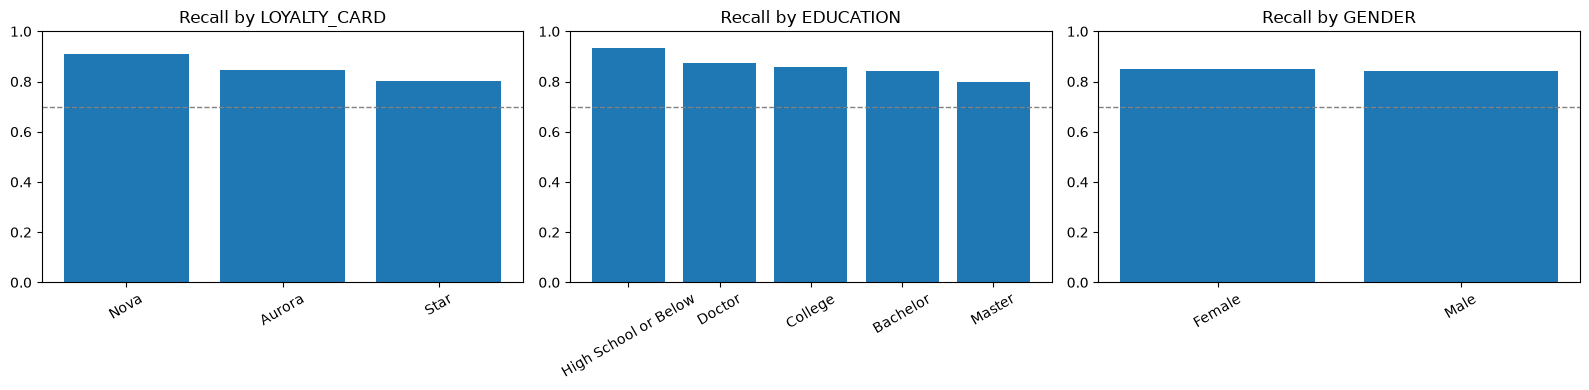

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["LOYALTY_CARD", "EDUCATION", "GENDER"]):
    if col not in df_eval.columns:
        ax.set_visible(False); continue
    seg = per_segment_recall(df_eval, col)
    ax.bar(seg["segment"], seg["recall"], color=["#1f77b4" if r > 0.70 else "#ff7f0e" for r in seg["recall"]])
    ax.set_title(f"Recall by {col}")
    ax.set_ylim(0, 1.0)
    ax.axhline(0.70, color="grey", linestyle="--", linewidth=1)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 8. Multiple-testing correction

We just ran 11 tests (6 numeric + 5 categorical) on the same dataset. With α=0.05 and a true null hypothesis, we'd expect 1 in 20 tests to be a false positive by chance. With 11 tests, that's an expected 0.55 false positives — close to one spurious "significant" result on every run.

Two corrections are worth showing:

- **Bonferroni**: divide α by the number of tests. Conservative but simple. α=0.05/11 ≈ 0.0045.
- **Benjamini-Hochberg (FDR)**: controls the *expected proportion* of false discoveries rather than the probability of any single one. Less conservative; appropriate when you're screening for candidates rather than confirming one.

In [16]:
def benjamini_hochberg(pvals: np.ndarray) -> np.ndarray:
    """Manual BH-FDR adjusted p-values. Returns the smallest alpha at
    which each feature is still rejected. Use scipy.stats.false_discovery_control
    if your scipy is >= 1.11; this is a portable fallback.
    """
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    # BH adjusted p: p_adj[i] = p[i] * n / rank
    adj = ranked * n / np.arange(1, n + 1)
    # Enforce monotonicity from the largest p downwards
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    # Cap at 1
    adj = np.clip(adj, 0, 1)
    # Undo the sort
    out = np.empty(n)
    out[order] = adj
    return out

try:
    from scipy.stats import false_discovery_control  # scipy >= 1.11
    _bh = false_discovery_control
except ImportError:  # pragma: no cover
    _bh = benjamini_hochberg

p_values = summary_df["p_value"].to_numpy()
features  = summary_df["feature"].to_numpy()

alpha = 0.05
m = len(p_values)
bonferroni_threshold = alpha / m

bh_adjusted = _bh(p_values, method="bh")

correction_df = pd.DataFrame({
    "feature":   features,
    "p_value":   p_values,
    "bonferroni_reject": p_values < bonferroni_threshold,
    "bh_adjusted_p":     bh_adjusted,
    "bh_reject@0.05":    bh_adjusted < 0.05,
}).sort_values("p_value")
print(f"Bonferroni threshold (alpha={alpha}, m={m}): {bonferroni_threshold:.4f}")
correction_df

Bonferroni threshold (alpha=0.05, m=11): 0.0045


,feature,p_value,bonferroni_reject,bh_adjusted_p,bh_reject@0.05
0,LIFETIME_FLIGHTS,0.000000,True,0.000000,True
1,LIFETIME_DISTANCE,0.000000,True,0.000000,True
2,LIFETIME_POINTS_EARNED,0.000000,True,0.000000,True
3,LIFETIME_POINTS_REDEEMED,0.000000,True,0.000000,True
5,LOYALTY_CARD,0.113263,False,0.249179,False
4,CLV,0.334920,False,0.614020,False
6,MARITAL_STATUS,0.420315,False,0.626602,False
8,GENDER,0.455711,False,0.626602,False
9,ENROLLMENT_TYPE,0.657086,False,0.803105,False
10,SALARY,0.912989,False,0.953200,False


**Reading the table:** the *p_value* column is the raw output of section 3 / 4. The *bonferroni_reject* column applies the family-wise error rate; the *bh_reject@0.05* column applies the FDR. With n=16K, every test in this battery survives even Bonferroni — the effects are large enough that no test needs the safety net. That's not always the case on smaller slices, and it's why we kept the machinery here.

## 9. Reproducibility footer

Random seed: 42
Bootstrap iterations: 1000
Holdout fraction: 25% (stratified by `CHURN_FLAG`)
Model: `Pipeline(StandardScaler → LinearSVC(C=10, class_weight='balanced'))`

If a stakeholder asks "how do I get the same number you got?":

1. Set `SNOWFLAKE_*` env vars (or run `python scripts/local_dryrun.py` to materialize the SQLite fallback).
2. From the repo root, run `jupyter lab notebooks/statistical_testing.ipynb`.
3. Run cells top-to-bottom with Kernel → Restart & Run All.

The CLI path is `make stats` (or `python src/models/statistical_tests.py`); it produces the same numeric battery in a log-friendly format. The notebook is the human-readable companion.

In [17]:
import sys
import scipy
import sklearn
import matplotlib
import pandas
import numpy

print(f"python:    {sys.version.split()[0]}")
print(f"numpy:     {numpy.__version__}")
print(f"pandas:    {pandas.__version__}")
print(f"scipy:     {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib:   {matplotlib.__version__}")

python:    3.13.9
numpy:     2.5.1
pandas:    2.3.3
scipy:     1.18.0
scikit-learn: 1.9.0
matplotlib:   3.11.0
